In [1]:
import pickle

import feyn
import numpy as np
import pandas as pd
import torch
from autora.theorist.bms import BMSRegressor
from feyn import Model
from gplearn.functions import make_function
from gplearn.genetic import SymbolicRegressor
from kan import KAN, create_dataset
from kan.utils import add_symbolic
from matplotlib import font_manager
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


This version of Feyn and the QLattice is available for academic, personal, and non-commercial use. By using the community version of this software you agree to the terms and conditions which can be found at https://abzu.ai/eula.

# KAN、遗传编程与贝叶斯方法的符号回归对比
本笔记本在同一任务下比较四种**符号回归**方法，对目标**多变量**函数进行建模：
$$
y = \sin(x_1^2) + e^{\frac{x_2}{4}} + 1
$$

1. **Kolmogorov-Arnold Networks (KAN)**：使用官方 **PyKAN** 进行训练。
2. **遗传编程（Genetic Programming）**：使用 **gplearn**，通过进化搜索符号表达式。
3. **贝叶斯符号回归（BSR）**：使用 [autora](https://pypi.org/project/autora/) 完成贝叶斯建模。
4. **QLattice**：QLattice 是 [SRBench Competition 2022](https://cavalab.org/srbench/competition-2022/) Synthetic Track 冠军方案。

## 数据集与可视化

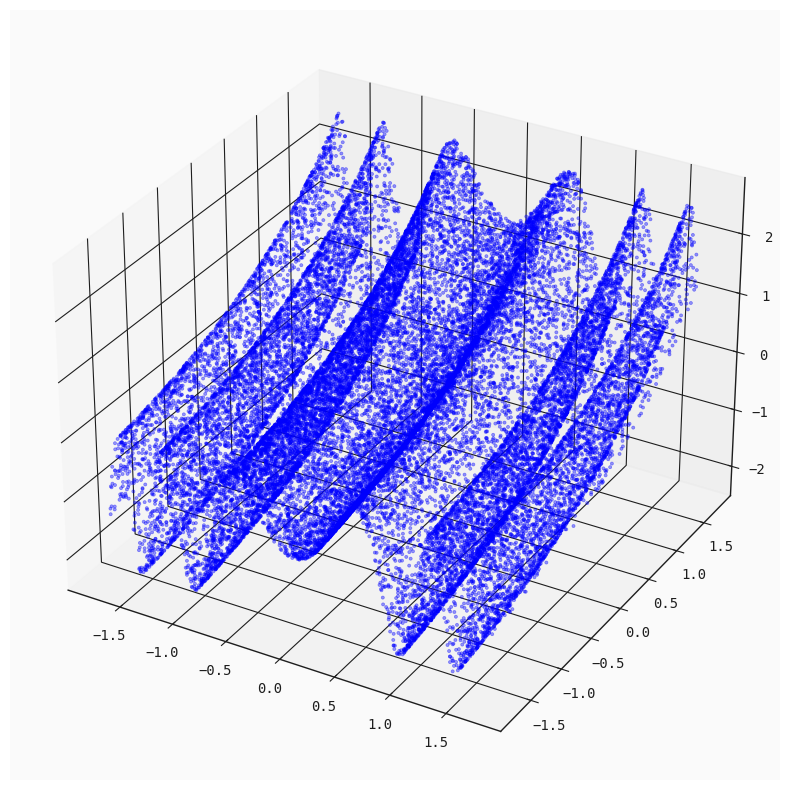

In [2]:
sin_exp = lambda x: torch.sin(x[:, 0] ** 2) + torch.exp(x[:, 1] / 4) + 1
noise_std = .05
dataset = create_dataset(sin_exp, n_var=2, ranges=[-4, 4], train_num=30000, test_num=5000,
                         normalize_input=True, normalize_label=True)
# dataset['train_label'] += np.random.normal(0, noise_std, (1000, ))
Xs, Ys = dataset['train_input'], dataset['train_label']
X_test, Y_test = dataset['test_input'], dataset['test_label']

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10))
ax.scatter(Xs[:, 0], Xs[:, 1], Ys[:, 0], c='blue', marker='.', alpha=0.4, linewidths=.5)
plt.show()

## 1. KAN 方法

In [3]:
# kan_model = KAN.loadckpt('model/multivariate_kan_model')
# kan_model.plot()

In [4]:
kan_model = KAN(width=[2, 2, 1], grid=4, k=3)
pass

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.17e-02 | test_loss: 3.17e-02 | reg: 1.40e+01 | : 100%|█| 50/50 [02:15<00:00,  2.71s/


saving model version 0.1


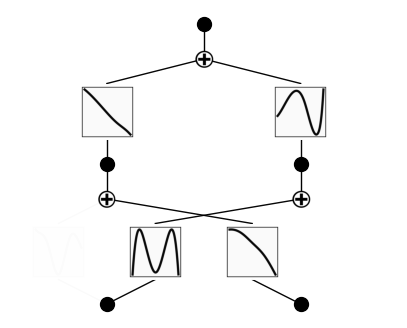

In [5]:
kan_model.fit(dataset, opt='LBFGS', batch=-1, steps=50, lamb=0.001, lamb_entropy=4)
kan_model.plot()
# kan_model.saveckpt('model/multivariate_kan_model')

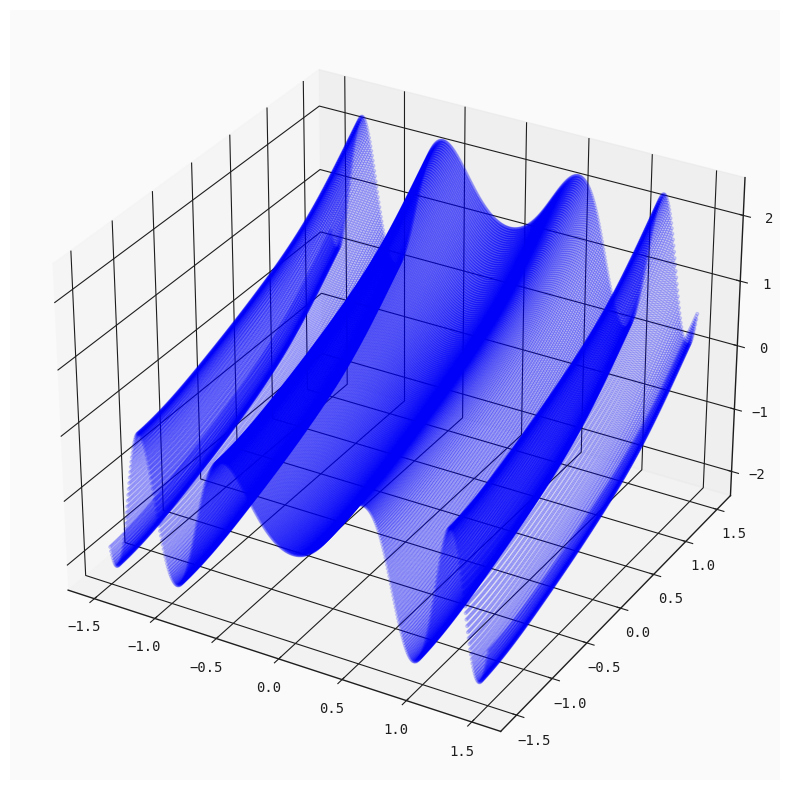

In [6]:
Xs2 = torch.cartesian_prod(torch.linspace(-1.5, 1.5, 500), torch.linspace(-1.5, 1.5, 200))
with torch.no_grad():
    Ys2 = kan_model(Xs2)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Xs2[:, 0], Xs2[:, 1], Ys2[:, 0], c='blue', marker='.', alpha=0.15, linewidths=0.75)
plt.show()

## 2. Gplearn 方法

In [7]:
# with open("multivariate_gplearn_model.pkl", "rb") as f:
#     genetic_model: SymbolicRegressor = pickle.load(f)

In [8]:
def _exponent(x):
    with np.errstate(divide='ignore', invalid='ignore'):
        a = np.exp(x)
        a[np.greater(a, 10)] = 10
        a[np.less(a, 1 / 10.)] = 1 / 10.
        return a


exp = make_function(function=_exponent, name='exp', arity=1)
genetic_model = SymbolicRegressor(
    population_size=20000,
    generations=5,
    init_depth=(4, 10),
    metric='mse',
    function_set=('add', 'mul', 'sin', exp),
    n_jobs=-1,
    verbose=1,
)

In [9]:
genetic_model.fit(Xs, Ys)
# with open("multivariate_gplearn_model.pkl", "wb") as f:
#     pickle.dump(genetic_model, f)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    46.41      2.21684e+13       19         0.508121              N/A      1.56m
   1    18.28          3.59768       17         0.499561              N/A     51.14s
   2     4.23          14.7033       17         0.499561              N/A     35.02s
   3     4.22          1.88302       18         0.497849              N/A     35.44s
   4     3.97         0.990406       18         0.497849              N/A      0.00s


SymbolicRegressor(function_set=('add', 'mul', 'sin',
                                <gplearn.functions._Function object at 0x000001D71B07CF40>),
                  generations=5, init_depth=(4, 10), metric='mse', n_jobs=-1,
                  population_size=20000, verbose=1)

## 3. BMS Regressor 方法

In [10]:
# with open("multivariate_bms_model.pkl", "rb") as f:
#     bms_model: BMSRegressor = pickle.load(f)

In [11]:
def _to_numpy_2d(values):
    if isinstance(values, torch.Tensor):
        values = values.detach().cpu().numpy()
    return np.asarray(values, dtype=np.float64)

def _to_numpy_1d(values):
    return _to_numpy_2d(values).reshape(-1)

X_bms = _to_numpy_2d(Xs)
y_bms = _to_numpy_1d(Ys)

# Tune on a subset first to reduce runtime while improving stability.
sample_cap = 12000
if X_bms.shape[0] > sample_cap:
    rng = np.random.default_rng(42)
    tune_idx = rng.choice(X_bms.shape[0], size=sample_cap, replace=False)
    X_tune = X_bms[tune_idx]
    y_tune = y_bms[tune_idx]
else:
    X_tune = X_bms
    y_tune = y_bms

X_train_bms, X_val_bms, y_train_bms, y_val_bms = train_test_split(
    X_tune,
    y_tune,
    test_size=0.25,
    random_state=42,
)

bms_candidates = [
    {
        'epochs': 30,
        'ts': [1.0, 1.01, 1.0201, 1.030301, 1.04060401, 1.0510100501],
    },
    {
        'epochs': 50,
        'ts': [1.0, 1.01, 1.0201, 1.030301, 1.04060401, 1.0510100501],
    },
    {
        'epochs': 50,
        'ts': [1.0, 1.005, 1.010025, 1.015075125, 1.020150500625, 1.025251253128125, 1.0303775093937656],
    },
]

bms_search_results = []
for i, params in enumerate(bms_candidates, start=1):
    try:
        candidate = BMSRegressor(epochs=params['epochs'], ts=params['ts'])
        candidate.fit(X_train_bms, y_train_bms)
        val_pred = np.asarray(candidate.predict(X_val_bms)).reshape(-1)
        mse = mean_squared_error(y_val_bms, val_pred)
        r2 = r2_score(y_val_bms, val_pred)
        bms_search_results.append({'params': params, 'mse': mse, 'r2': r2})
        print(f"[BMS candidate {i}] epochs={params['epochs']} ts_len={len(params['ts'])} | MSE={mse:.6f}, R2={r2:.6f}")
    except Exception as e:
        print(f"[BMS candidate {i}] failed: {e}")

if not bms_search_results:
    raise RuntimeError('All BMS candidates failed during tuning.')

best_bms = min(bms_search_results, key=lambda x: x['mse'])
print(f"Best BMS params: {best_bms['params']}")

bms_model = BMSRegressor(**best_bms['params'])
try:
    bms_model.fit(X_bms, y_bms)
    # with open("multivariate_bms_model.pkl", "wb") as f:
    #     pickle.dump(bms_model, f)
except Exception as e:
    print(f"Error during full-data BMS fit: {e}")
    print('Falling back to tuned subset for BMS fit.')
    bms_model.fit(X_tune, y_tune)


BMS fitting started

100%|██████████| 30/30 [00:10<00:00,  2.91it/s]


BMS fitting finished

[BMS candidate 1] epochs=30 ts_len=6 | MSE=0.550856, R2=0.459445


BMS fitting started

...

BMS fitting finished

[BMS candidate 3] epochs=50 ts_len=7 | MSE=0.529526, R2=0.480377
Best BMS params: {'epochs': 50, 'ts': [1.0, 1.01, 1.0201, 1.030301, 1.04060401, 1.0510100501]}


BMS fitting started

100%|██████████| 50/50 [00:51<00:00,  1.04s/it]


BMS fitting finished

## 4. QLattice 方法

In [12]:
# with open("multivariate_qlattice_model.pkl", "rb") as f:
#     qlattice_models: list[Model] = pickle.load(f)

In [13]:
ql = feyn.QLattice()

def _to_float64_1d(values):
    if isinstance(values, torch.Tensor):
        values = values.detach().cpu().numpy()
    return np.asarray(values, dtype=np.float64).reshape(-1)

data = pd.DataFrame({
    'x1': _to_float64_1d(Xs[:, 0]),
    'x2': _to_float64_1d(Xs[:, 1]),
    'y': _to_float64_1d(Ys)
})
qlattice_models = ql.auto_run(data, output_name='y', n_epochs=20)

In [14]:
qlattice_models[0].fit(data)
# with open("multivariate_qlattice_model.pkl", "wb") as f:
#     pickle.dump(qlattice_models, f)

In [15]:
sympy_model = qlattice_models[0].sympify(signif=2)
sympy_model.as_expr()

-0.96*log(exp(-0.64*(0.57*x2 + 1)**2 - 8.1*(exp(-8.6e-5*(0.72 - x2)**2 - 6.4*(1 - 0.83*x1)**2*(0.82*x1 + 1)**2) - 0.46)**2)) - 2.0

## 模型结果对比

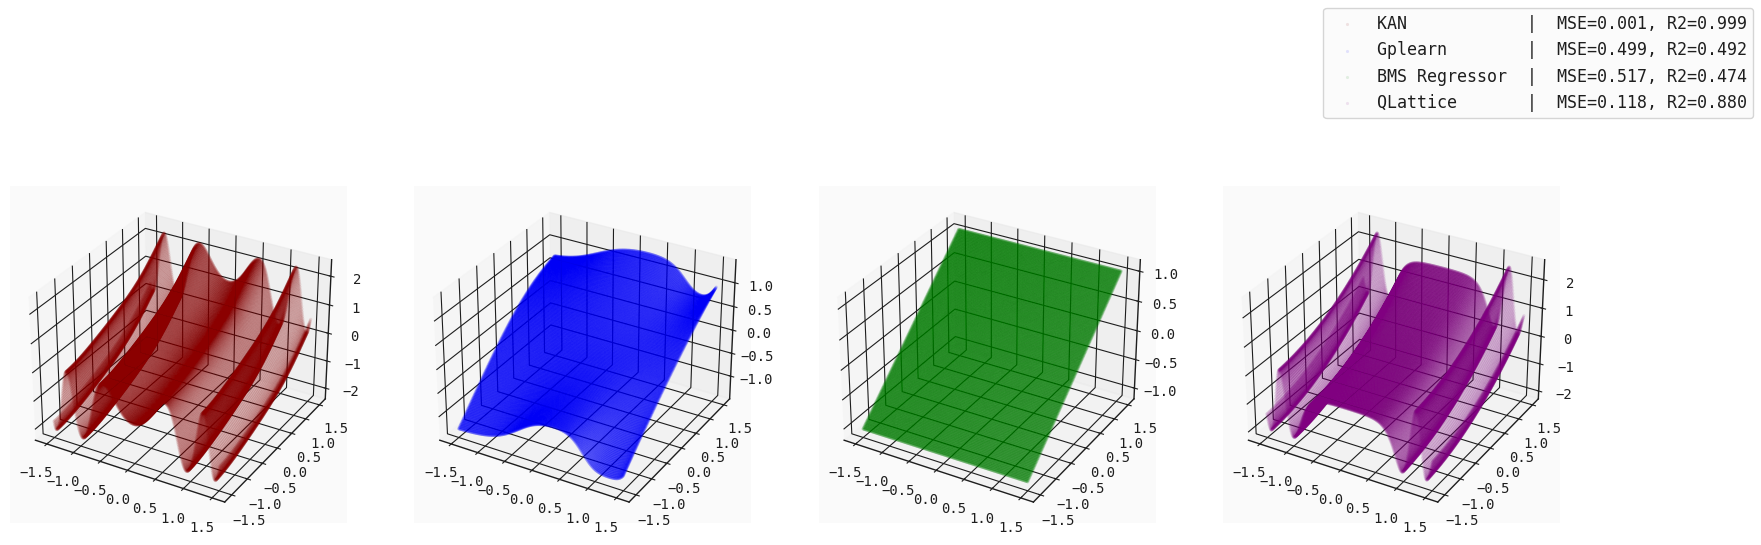

In [16]:
Xs2 = torch.cartesian_prod(torch.linspace(-1.5, 1.5, 500), torch.linspace(-1.5, 1.5, 150))
x_test_np = _to_numpy_2d(X_test)
x_grid_np = _to_numpy_2d(Xs2)
y_test_eval = _to_numpy_1d(Y_test)

with torch.no_grad():
    kan_pred = _to_numpy_1d(kan_model(X_test)[:, 0]), _to_numpy_1d(kan_model(Xs2)[:, 0])
    genetic_pred = _to_numpy_1d(genetic_model.predict(x_test_np)), _to_numpy_1d(genetic_model.predict(x_grid_np))
    bms_pred = _to_numpy_1d(bms_model.predict(x_test_np)), _to_numpy_1d(bms_model.predict(x_grid_np))
    qlattice_pred = qlattice_models[0].predict(pd.DataFrame({
        'x1': _to_float64_1d(X_test[:, 0]),
        'x2': _to_float64_1d(X_test[:, 1]),
    })), qlattice_models[0].predict(pd.DataFrame({
        'x1': _to_float64_1d(Xs2[:, 0]),
        'x2': _to_float64_1d(Xs2[:, 1]),
    }))

fig = plt.figure(figsize=(20, 7))
models = [('KAN', kan_pred, fig.add_subplot(141, projection='3d'), 'darkred'),
          ('Gplearn', genetic_pred, fig.add_subplot(142, projection='3d'), 'blue'),
          ('BMS Regressor', bms_pred, fig.add_subplot(143, projection='3d'), 'green'),
          ('QLattice', qlattice_pred, fig.add_subplot(144, projection='3d'), 'purple')
          ]
handles = []
for pred in models:
    mse, r2 = mean_squared_error(y_test_eval, pred[1][0]), r2_score(y_test_eval, pred[1][0])
    handles.append(pred[2].scatter(Xs2[:, 0], Xs2[:, 1], pred[1][1],
                                   label=f'{pred[0]}{" " * (max(map(lambda x: len(x[0]), models)) - len(pred[0]))}  |  MSE={mse:.3f}, R2={r2:.3f}',
                                   alpha=0.1, c=pred[3], marker='.', linewidths=0.01))
fig.legend(handles, map(lambda x: x.get_label(), handles),
           prop=font_manager.FontProperties(family='monospace', size=12))